# 🎵 What Makes a Song Popular? — Spotify Audio Feature Analysis
**Author:** Nobel Tedros  
**Dataset:** [Spotify Tracks Dataset (Kaggle)](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)  

## Goal
Use Spotify's audio feature data to explore what separates popular songs from the rest.  
Spotify provides numerical descriptors for every song — we'll use correlation analysis and regression  
to identify which audio features show the **strongest statistical association** with popularity.

> **Note on causality:** This analysis is observational. The relationships found are correlational,  
> not causal. A feature being associated with popularity does not mean it drives popularity.

Topics covered:
- Data loading, cleaning & filtering
- EDA with visualizations (distributions, genre breakdowns, feature comparisons)
- Pearson correlation analysis
- Ridge regression to model the relationship between audio features and popularity

---

## ⚙️ Setup: How to Get the Dataset
1. Go to: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
2. Click **Download** (free Kaggle account required)
3. Unzip — you will get 
4. Place  in the **same folder as this notebook**
5. Run all cells top to bottom ()

---

### Audio Feature Glossary
| Feature | What it means |
|---|---|
|  | 0–100 score assigned by Spotify based on recent streams |
|  | How suitable for dancing (tempo, rhythm stability, beat) |
|  | Perceptual intensity and activity (loud, fast = high energy) |
|  | Musical positiveness — high = happy, low = sad/angry |
|  | Beats per minute (BPM) |
|  | Average loudness in decibels (dB) |
|  | Confidence the track is acoustic (0.0–1.0) |
|  | Predicts whether a track has no vocals |
|  | Presence of spoken words |
|  | Detects presence of a live audience |
|  | Track length in milliseconds |


# 🎵 What Makes a Song Popular? — Spotify Audio Feature Analysis
**Author:** Nobel Tedros  
**Dataset:** [Spotify Tracks Dataset (Kaggle)](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)  

## Goal
Use Spotify's audio feature data to understand what separates popular songs from the rest.  
Spotify provides numerical descriptors for every song — we'll use statistics and machine learning  
to find out which ones actually drive popularity.

Topics covered:
- Data loading, inspection & cleaning
- Exploratory Data Analysis — distributions, genre breakdowns, feature comparisons
- Pearson correlation analysis (which audio features predict popularity?)
- Scatter plots & heatmaps
- Linear regression model to predict popularity score

---
### Audio Feature Glossary
| Feature | What it means |
|---|---|
| `popularity` | 0–100 score assigned by Spotify based on recent streams |
| `danceability` | How suitable for dancing (tempo, rhythm stability, beat) |
| `energy` | Perceptual intensity and activity (loud, fast = high energy) |
| `valence` | Musical positiveness — high = happy, low = sad/angry |
| `tempo` | Beats per minute (BPM) |
| `loudness` | Average loudness in decibels (dB) |
| `acousticness` | Confidence the track is acoustic (0.0–1.0) |
| `instrumentalness` | Predicts whether a track has no vocals |
| `speechiness` | Presence of spoken words (podcasts = high, music = low) |
| `liveness` | Detects presence of a live audience |
| `duration_ms` | Track length in milliseconds |


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load the Data
Download from Kaggle: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset  
Place `dataset.csv` in the same folder as this notebook.

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# low_memory=False suppresses DtypeWarning caused by mixed-type columns in this CSV
df = pd.read_csv('dataset.csv', index_col=0, low_memory=False)

print(f'Shape: {df.shape}')  # ~114,000 tracks across 125 genres
df.head()


Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# ── Inspect ───────────────────────────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe()

=== Data Types ===
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

=== Missing Values ===
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo    

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2. Cleaning & Filtering

In [4]:
# ── Remove duplicates and junk rows ──────────────────────────────────────────
# Drop duplicate track IDs — same song can appear in multiple genre playlists
df.drop_duplicates(subset='track_id', inplace=True)

# Drop rows missing any audio features or popularity
audio_features = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
df.dropna(subset=audio_features, inplace=True)

# Filter out tracks with 0 popularity — these are essentially unlisted/unreleased
# Keeping them would skew our analysis toward songs nobody has heard
df = df[df['popularity'] > 0]

# Convert duration from milliseconds to seconds for readability
df['duration_s'] = df['duration_ms'] / 1000

df.reset_index(drop=True, inplace=True)
print(f'Clean dataset shape: {df.shape}')

Clean dataset shape: (80293, 21)


In [5]:
# ── Define "hit" songs ────────────────────────────────────────────────────────
# We'll label the top 25% most popular tracks as "hits" for comparison plots
hit_threshold = df['popularity'].quantile(0.75)
df['is_hit'] = (df['popularity'] >= hit_threshold).astype(int)

print(f'Hit threshold (75th percentile): popularity >= {hit_threshold}')
print(f'Number of hits: {df["is_hit"].sum():,}  |  Other tracks: {(df["is_hit"]==0).sum():,}')

Hit threshold (75th percentile): popularity >= 50.0
Number of hits: 21,209  |  Other tracks: 59,084


## 3. Exploratory Data Analysis

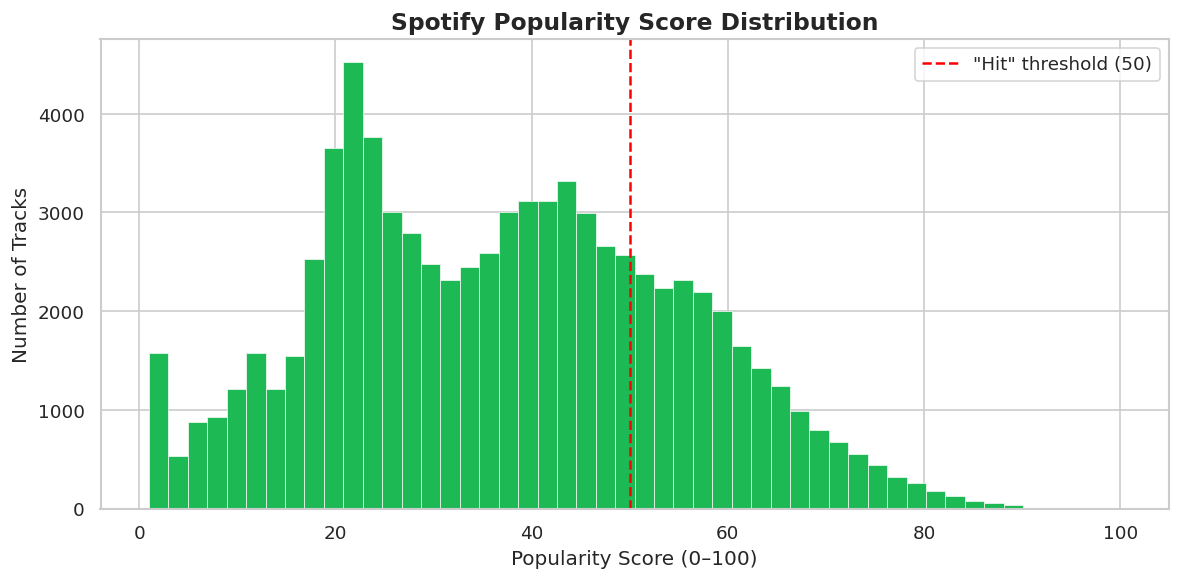

In [6]:
# ── Popularity distribution ───────────────────────────────────────────────────
# Most songs cluster in the middle — true hits are rare
fig, ax = plt.subplots()
ax.hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white', linewidth=0.4)
ax.axvline(hit_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'"Hit" threshold ({hit_threshold:.0f})')
ax.set_title('Spotify Popularity Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Number of Tracks')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_popularity_distribution.png', bbox_inches='tight')
plt.show()

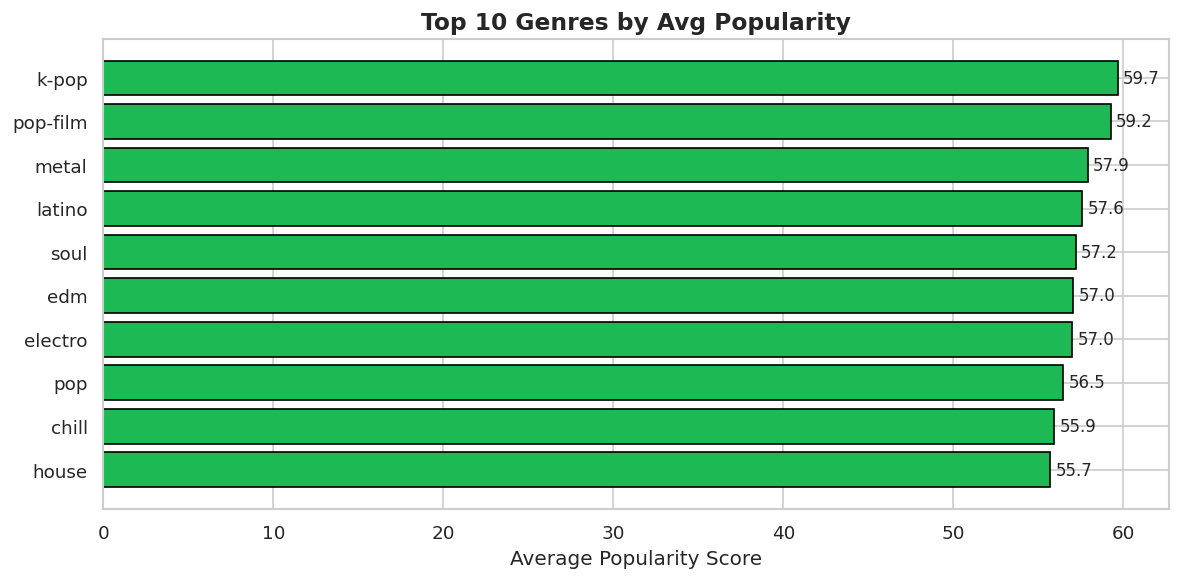

In [7]:
# ── Top 10 genres by average popularity ──────────────────────────────────────
# Which genres consistently produce popular tracks?
# Require at least 50 tracks per genre for statistical reliability
genre_pop = (
    df.groupby('track_genre')
    .agg(avg_popularity=('popularity', 'mean'), count=('popularity', 'count'))
    .query('count >= 50')
    .nlargest(10, 'avg_popularity')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(genre_pop['track_genre'][::-1], genre_pop['avg_popularity'][::-1],
               color='#1DB954', edgecolor='black')
ax.set_title('Top 10 Genres by Avg Popularity', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Popularity Score')
for bar, val in zip(bars, genre_pop['avg_popularity'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig2_top_genres.png', bbox_inches='tight')
plt.show()

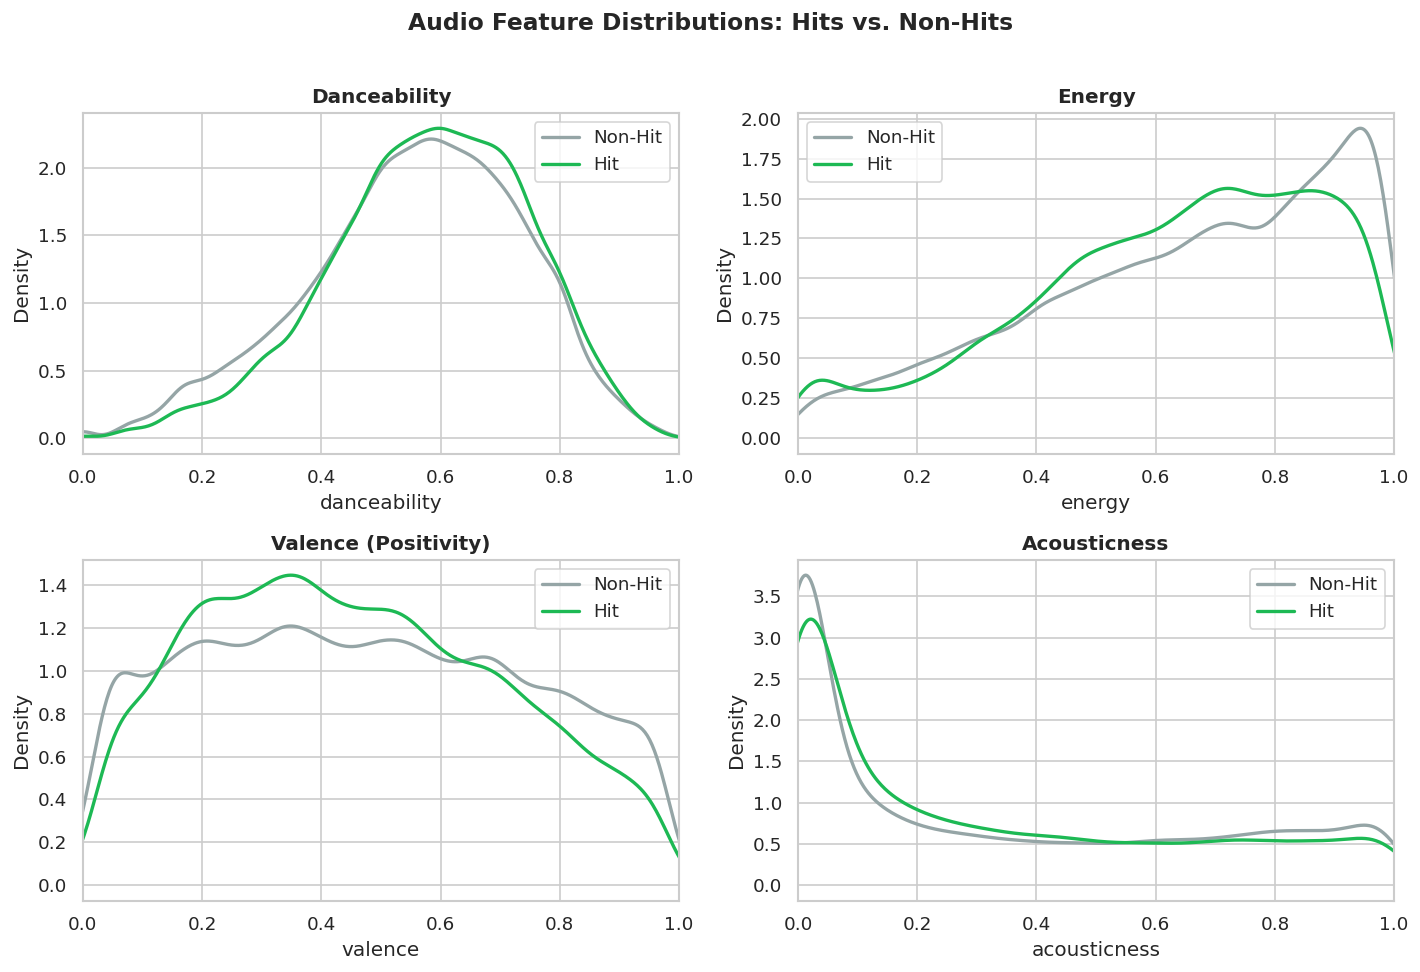

In [8]:
# ── Audio feature distributions: Hits vs. Non-Hits ────────────────────────────
# Side-by-side KDE plots show where hits differ from average tracks
features_to_plot = ['danceability', 'energy', 'valence', 'acousticness']
feature_labels   = ['Danceability', 'Energy', 'Valence (Positivity)', 'Acousticness']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

hits     = df[df['is_hit'] == 1]
non_hits = df[df['is_hit'] == 0]

for ax, feat, label in zip(axes, features_to_plot, feature_labels):
    # KDE = Kernel Density Estimate — smooth version of a histogram
    non_hits[feat].plot(kind='density', ax=ax, color='#95a5a6', label='Non-Hit', linewidth=2)
    hits[feat].plot(kind='density', ax=ax, color='#1DB954', label='Hit', linewidth=2)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_xlim(0, 1)

plt.suptitle('Audio Feature Distributions: Hits vs. Non-Hits', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_hit_vs_nonhit_features.png', bbox_inches='tight')
plt.show()

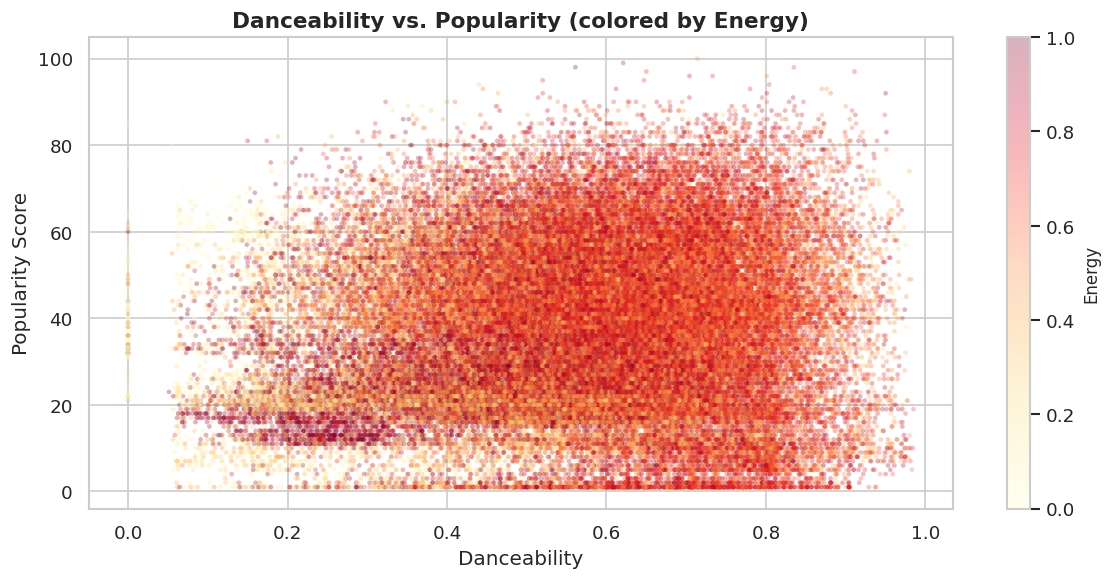

In [9]:
# ── Danceability vs. Popularity scatter ───────────────────────────────────────
# Color points by energy level to add a 3rd dimension
fig, ax = plt.subplots()
scatter = ax.scatter(
    df['danceability'], df['popularity'],
    c=df['energy'], cmap='YlOrRd',
    alpha=0.3, s=8, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy', fontsize=10)
ax.set_title('Danceability vs. Popularity (colored by Energy)', fontsize=13, fontweight='bold')
ax.set_xlabel('Danceability')
ax.set_ylabel('Popularity Score')
plt.tight_layout()
plt.savefig('fig4_danceability_vs_popularity.png', bbox_inches='tight')
plt.show()

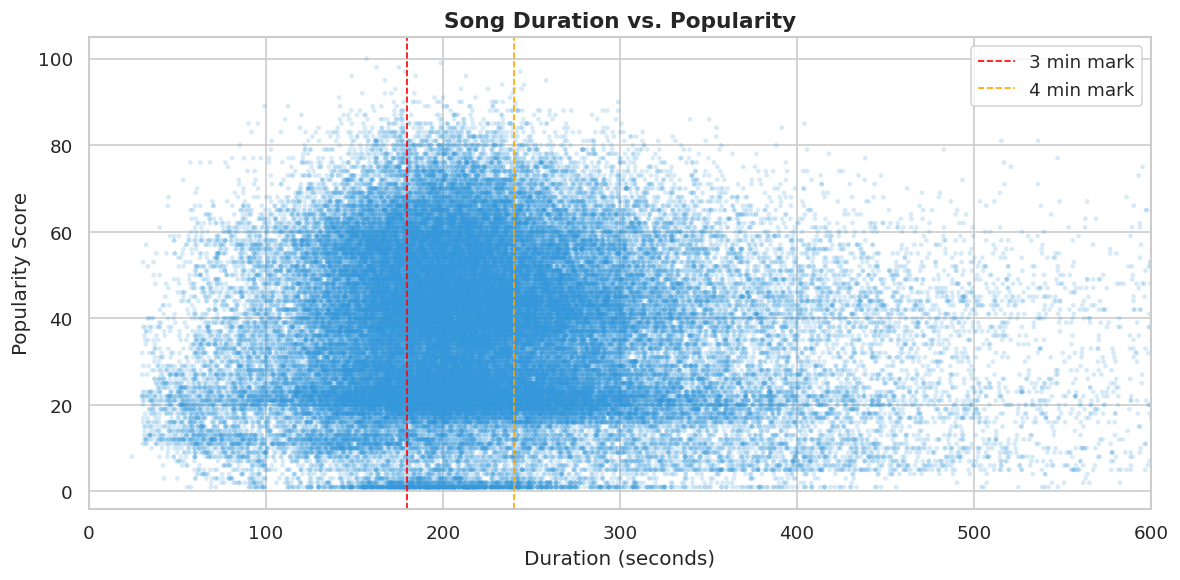

In [10]:
# ── Song duration vs. Popularity ──────────────────────────────────────────────
# Does song length matter? The streaming era has pushed songs shorter.
fig, ax = plt.subplots()
ax.scatter(df['duration_s'], df['popularity'],
           color='#3498db', alpha=0.2, s=8, edgecolors='none')
ax.set_xlim(0, 600)   # cap at 10 minutes — removes podcast/classical outliers
ax.axvline(180, color='red', linestyle='--', linewidth=1, label='3 min mark')
ax.axvline(240, color='orange', linestyle='--', linewidth=1, label='4 min mark')
ax.set_title('Song Duration vs. Popularity', fontsize=13, fontweight='bold')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Popularity Score')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_duration_vs_popularity.png', bbox_inches='tight')
plt.show()

## 4. Pearson Correlation Analysis
Which audio features show the **strongest statistical association** with popularity?  
Pearson r measures linear correlation — positive values mean the feature tends to increase  
alongside popularity; negative means the opposite. This does not imply causation.


In [11]:
# ── Pearson r: each audio feature vs. popularity ──────────────────────────────
# Same method used in the NFL pre-snap motion project
candidate_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness',
                      'valence', 'tempo', 'duration_s']

results = []
for feat in candidate_features:
    r, p = stats.pearsonr(df[feat], df['popularity'])
    results.append({'Feature': feat, 'Pearson_r': round(r, 3), 'p_value': p})

corr_df = pd.DataFrame(results).sort_values('Pearson_r', key=abs, ascending=False)
print(corr_df.to_string(index=False))

         Feature  Pearson_r       p_value
instrumentalness     -0.195  0.000000e+00
     speechiness     -0.085 8.158655e-129
    danceability      0.074  2.630571e-98
        loudness      0.073  1.183672e-95
      duration_s     -0.060  2.276630e-65
        liveness     -0.050  3.681112e-46
          energy     -0.034  3.248559e-22
           tempo     -0.019  4.435381e-08
    acousticness     -0.007  5.311217e-02
         valence     -0.002  5.988858e-01


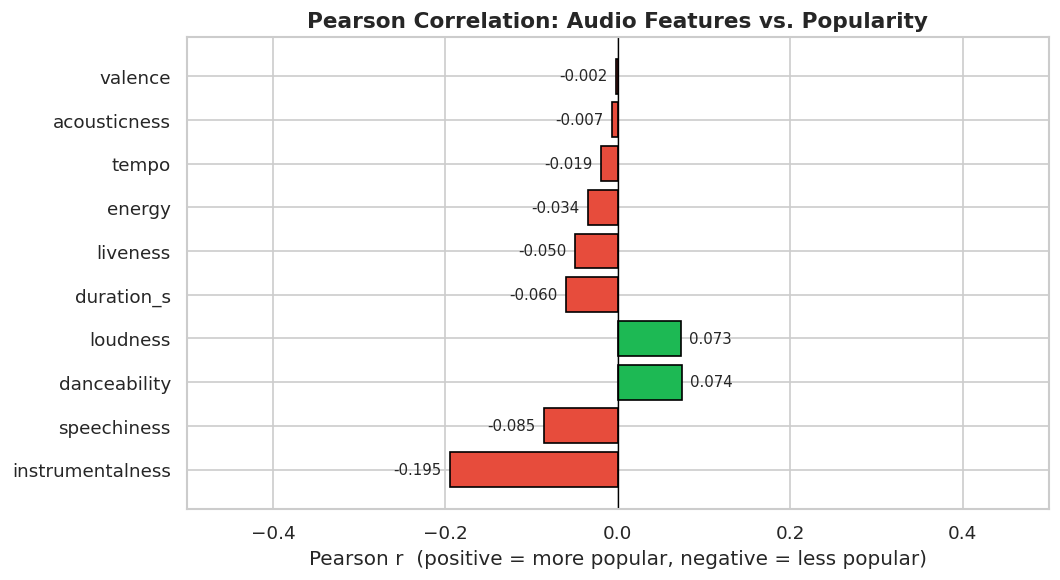

In [12]:
# ── Visualize Pearson correlations ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1DB954' if r > 0 else '#e74c3c' for r in corr_df['Pearson_r']]
bars = ax.barh(corr_df['Feature'], corr_df['Pearson_r'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation: Audio Features vs. Popularity', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r  (positive = more popular, negative = less popular)')
ax.set_xlim(-0.5, 0.5)

# Label each bar with its r value
for bar, r in zip(bars, corr_df['Pearson_r']):
    offset = 0.01 if r >= 0 else -0.01
    ha = 'left' if r >= 0 else 'right'
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f'{r:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('fig6_pearson_correlations.png', bbox_inches='tight')
plt.show()

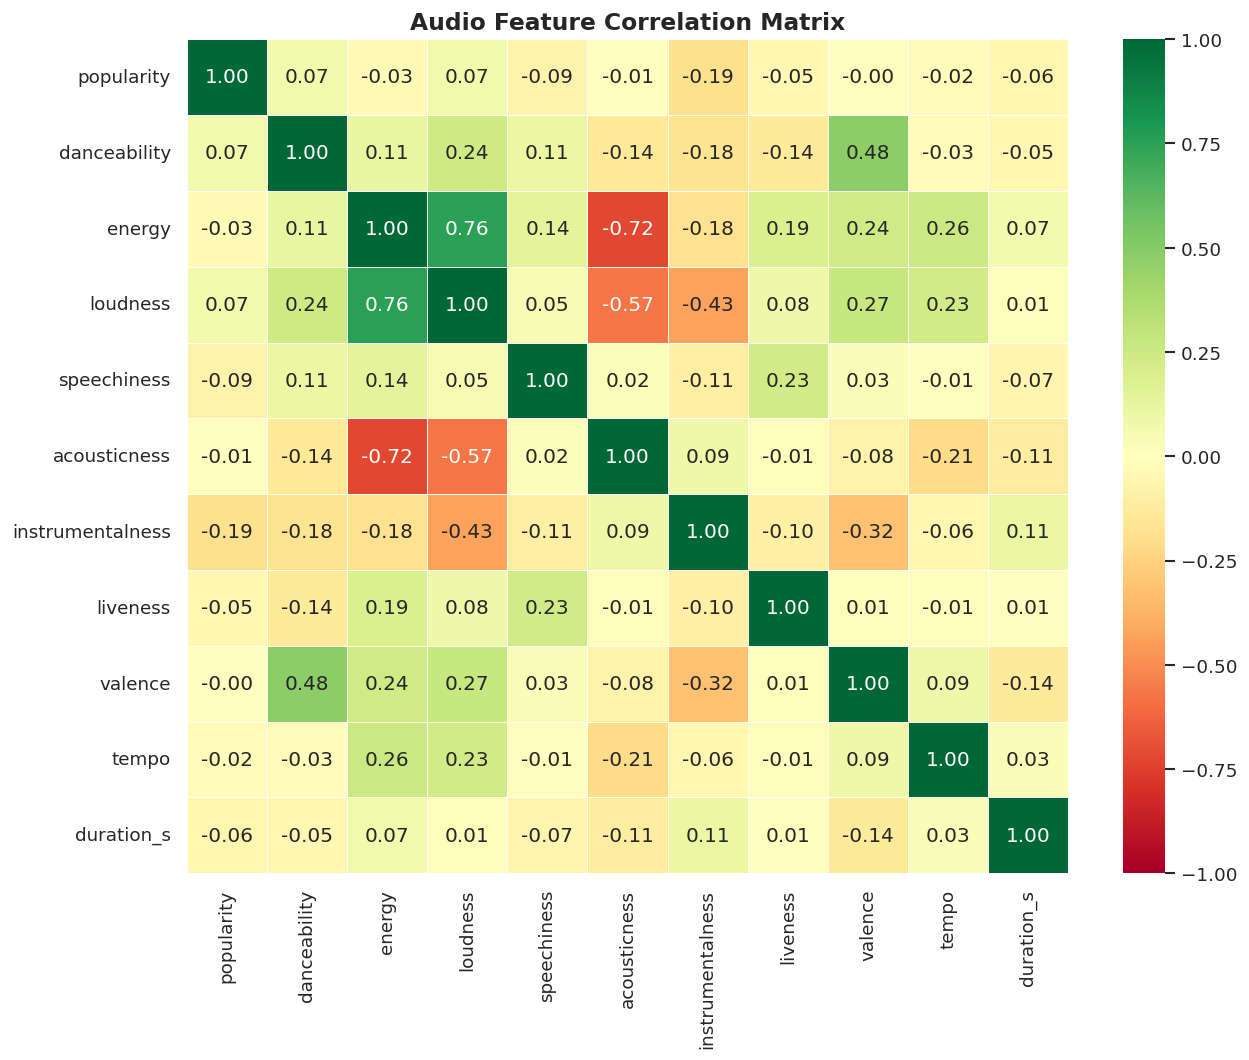

In [13]:
# ── Full correlation heatmap across all audio features ────────────────────────
# Shows relationships between features themselves, not just vs. popularity
heatmap_cols = ['popularity'] + candidate_features
corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Audio Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_full_heatmap.png', bbox_inches='tight')
plt.show()

# Notable: energy & loudness are highly correlated — makes sense (loud songs = energetic)
# energy & acousticness are strongly negatively correlated

## 5. Predicting Popularity with Ridge Regression
We use Ridge regression (a regularized form of linear regression) to predict popularity score from audio features.

In [14]:
# ── Build model ───────────────────────────────────────────────────────────────
model_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_s']

X = df[model_features]
y = df['popularity']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale — loudness is in dB (range ~-60 to 0), tempo in BPM (~60–200);
# scaling puts all features on the same footing
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Ridge regression: adds L2 penalty to reduce overfitting from correlated features
# (energy & loudness are correlated, so Ridge is better than plain linear regression here)
model = Ridge(alpha=1.0)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f'RMSE: {rmse:.2f} popularity points')
print(f'R²:   {r2:.3f}  ({r2*100:.1f}% of variance explained)')

RMSE: 17.59 popularity points
R²:   0.073  (7.3% of variance explained)


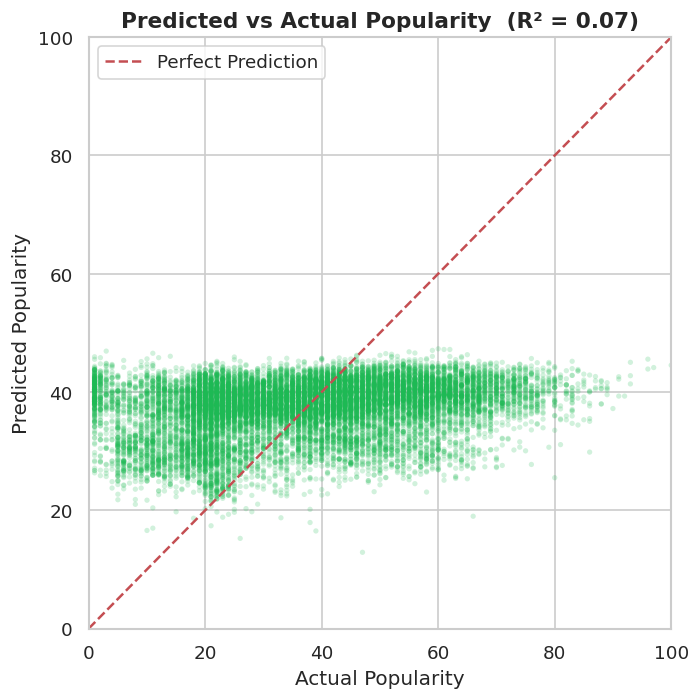

In [ ]:
# ── Predicted vs Actual ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.2, color='#1DB954', s=10, edgecolors='none')
lims = [0, 100]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_title(f'Predicted vs Actual Popularity  (R² = {r2:.2f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Popularity')
ax.set_ylabel('Predicted Popularity')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('fig8_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

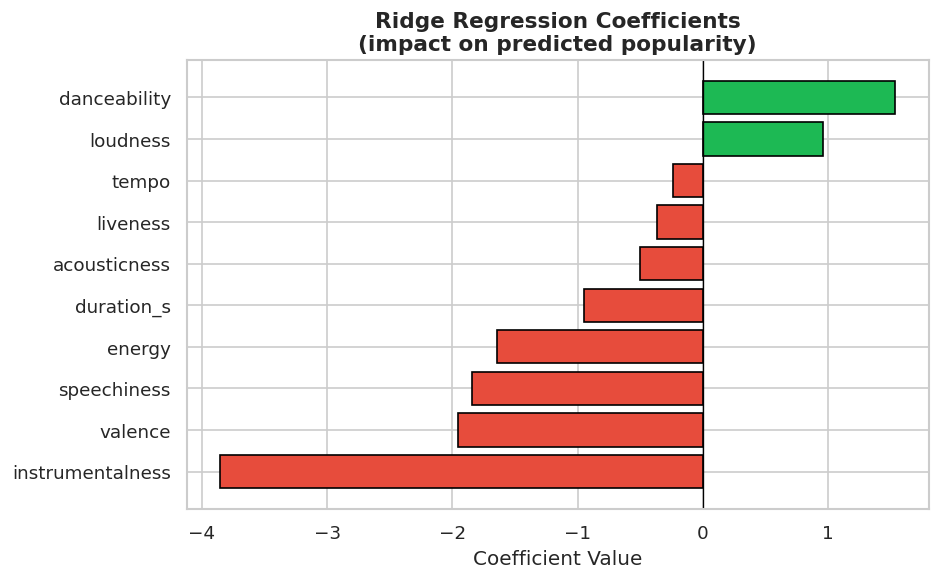

In [ ]:
# ── Feature coefficients ──────────────────────────────────────────────────────
# Which audio features push popularity up or down in the model?
coef_df = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#1DB954' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge Regression Coefficients\n(impact on predicted popularity)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('fig9_coefficients.png', bbox_inches='tight')
plt.show()

## 6. Conclusions & Portfolio Insights

### What the data actually shows

| Finding | Insight |
|---|---|
| **Instrumentalness** | Strongest *negative* association — tracks with vocals are significantly more popular than instrumentals |
| **Acousticness** | Negative association — produced, electric-sounding tracks are more strongly associated with popularity than acoustic ones |
| **Danceability** | Modest *positive* association — more danceable tracks tend to score slightly higher in popularity |
| **Duration** | Shorter tracks are associated with higher popularity — streaming has rewarded concision |
| **Valence** | Near-zero association — sad and happy songs reach similar popularity levels; mood alone does not predict success |
| **Model R² ≈ 0.07** | Audio features explain roughly 7% of the variance in popularity (RMSE ≈ 17.6 points on a 0–100 scale) |

### Why R² is low — and why that is the most interesting finding
A model R² of 0.07 is not a failure — it is the most honest result in this notebook.  
It tells us that **audio features alone account for only about 7% of what makes a song popular**.  
The other ~93% is driven by factors this dataset cannot capture: artist following, playlist placement,  
release timing, label marketing, and social media momentum. A song can sound perfect by every  
audio metric and still go nowhere. Conversely, a lo-fi track can go viral for reasons that have  
nothing to do with its BPM or danceability score.

### What I would do next
- **Add artist-level features** — follower count and prior hit history would likely explain far more variance than any audio feature
- **Era segmentation** — analyze whether the audio profile of popular songs has shifted meaningfully across decades
- **K-Means clustering** — group songs by audio fingerprint to discover sound archetypes (e.g. high-energy/low-acousticness vs. soft/acoustic)
- **Genre-stratified models** — a model trained only on hip-hop may behave very differently from one trained on classical
